# Студенческий workbook. Линейная регрессия vs логистическая регрессия

Этот ноутбук повторяет маршрут основного занятия, но в нем больше мест для ваших гипотез, промежуточных выводов и собственных экспериментов.

## Как работать

1. Сначала пишем гипотезу словами.
2. Потом решаем, чем проверять: графиком, таблицей, метрикой.
3. Только после этого запускаем код.
4. В конце обязательно пишем вывод человеческим языком.

## За что можно получить баллы

- `1 балл` за осмысленную гипотезу.
- `1 балл` за связь гипотезы с EDA.
- `1 балл` за корректную проверку.
- `1 балл` за рабочее улучшение модели.
- `+1 балл`, если вы объяснили, почему идея должна была помочь именно этой модели.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
# из-за квадратов сильно наказываются выбросы, сложно интерпретировать (просто непонятно как оценить, норм или не норм, из-за квадрата)
def mse_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


# мягче к выбросам и к ошибкам в целом (не штрафуется квадратом)
def mae_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


# сохраняет свойство наказания за выбросы, но легче интерпретировать
def rmse_manual(y_true, y_pred):
    return mse_manual(y_true, y_pred) ** 0.5


# отношение разности сумм квадратов в общем и ошибок
def r2_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot else 0.0


# процент отклонения от реальных данных
def mape_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    rmse = rmse_manual(y_true, y_pred)
    std_y = np.std(np.asarray(y_true, dtype=float))
    return {
        "R2": r2_manual(y_true, y_pred),
        "MAE": mae_manual(y_true, y_pred),
        "RMSE": rmse,
        "NRMSE": rmse / std_y if std_y else np.nan,
        "MAPE_%": mape_manual(y_true, y_pred),
    }


# точность - доля правильных ответов. accurancy=(tp+tn)/(tp+tn+ft+fn).
# "если будет дисбаланс классов, один класс будет больше влиять на метрику, чем другой. приоритет - качество определения"
def accuracy_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    return np.mean(y_true == pred)


# корректность - соотношение правильно угаданных среди.
# "он за то, чтобы мы не определяли негативный класс как положительный. приоритет - количество определённых"
def precision_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tp = np.sum((y_true == 1) & (pred == 1))
    fp = np.sum((y_true == 0) & (pred == 1))
    return tp / (tp + fp) if (tp + fp) else 0.0


# полнота - отношение предсказанных tp из всех РЕАЛЬНЫХ true.
# "про то, чтобы определять его как положительный"
def recall_manual(y_true, pred):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    tp = np.sum((y_true == 1) & (pred == 1))
    fn = np.sum((y_true == 1) & (pred == 0))
    return tp / (tp + fn) if (tp + fn) else 0.0


# среднее гармоническое между precision и recall. в отличие от обычного среднего, оно сильно наказывает модель, если одна из метрик близка к нулю. используется, когда важно и не пропускать объекты, и не ошибаться в прогнозах.
# "при 0.5 случайно угаданное. если ниже, нужно проверить инверсию. если больше, видимо, модель чему-то научилась"
def f1_manual(y_true, pred):
    precision = precision_manual(y_true, pred)
    recall = recall_manual(y_true, pred)
    return (
        2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    )


# здесь могла быть реализация Fb = (1 + b^2) * precision * recall / (precision + recall)
# b - вес полноты по отношению к корректности (точности)
# обобщенный для f1 (b=1)
#
# b>1: больший вес придается полноте (recall). модель сильнее наказывается за пропуск FN, чем FP.
# пример: важно найти все случаи болезни, даже если некоторые из них окажутся ложными (диагностика заболеваний)
#
# b<1: больший вес придается точности (precision). модель сильнее наказывается за пропуск FP, чем FN.
# пример: важно не ошибиться при определении положительного класса (спам-фильтр, где важно не поместить важное письмо в спам)


# наказывает модель, если она уверенно ошиблась
def logloss_manual(y_true, prob):
    y_true = np.asarray(y_true, dtype=float)
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    return -np.mean(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))


def classification_metrics(y_true, prob, pred):
    prob = np.clip(np.asarray(prob, dtype=float), 1e-6, 1 - 1e-6)
    pred = np.asarray(pred, dtype=int)
    return {
        "Accuracy": accuracy_manual(y_true, pred),
        "Precision": precision_manual(y_true, pred),
        "Recall": recall_manual(y_true, pred),
        "F1": f1_manual(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, prob),
        "LogLoss": logloss_manual(y_true, prob),
    }


# заполняет трейн и тест медианами
def fill_missing_from_train(X_train, X_test):
    if isinstance(X_train, pd.DataFrame):
        X_train_filled = X_train.copy()
        X_test_filled = X_test.copy()
        numeric_cols = X_train_filled.select_dtypes(include=[np.number]).columns
        medians = X_train_filled[numeric_cols].median()
        X_train_filled[numeric_cols] = X_train_filled[numeric_cols].fillna(medians)
        X_test_filled[numeric_cols] = X_test_filled[numeric_cols].fillna(medians)
        return X_train_filled, X_test_filled

    X_train_filled = np.asarray(X_train).copy()
    X_test_filled = np.asarray(X_test).copy()
    medians = np.nanmedian(X_train_filled, axis=0)
    train_nan = np.where(np.isnan(X_train_filled))
    test_nan = np.where(np.isnan(X_test_filled))
    if len(train_nan[0]) > 0:
        X_train_filled[train_nan] = np.take(medians, train_nan[1])
    if len(test_nan[0]) > 0:
        X_test_filled[test_nan] = np.take(medians, test_nan[1])
    return X_train_filled, X_test_filled


# преобразует массивы данных в матрицы
def to_numpy_2d(X):
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy(dtype=float)
    elif isinstance(X, pd.Series):
        X = X.to_frame().to_numpy(dtype=float)
    else:
        X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X


# создаёт столбец единиц, чтобы модель дополнительно вычислила w0
def add_bias(X):
    X_arr = to_numpy_2d(X)
    return np.column_stack([np.ones(len(X_arr)), X_arr])


# формула для линейной регрессии
def manual_linear_weights(X_train, y_train):
    Xb = add_bias(X_train)
    y_arr = np.asarray(y_train, dtype=float)
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y_arr


# предсказываем по весам
def manual_linear_predict(X, weights):
    return add_bias(X) @ weights


# стандартизация данных. теперь они одного масштаба (среднее - 0, отклонение - 1)
def standardize_train_test(X_train, X_test):
    X_train_arr = to_numpy_2d(X_train)
    X_test_arr = to_numpy_2d(X_test)
    mean = X_train_arr.mean(axis=0)
    std = X_train_arr.std(axis=0)
    std[std == 0] = 1.0
    return (X_train_arr - mean) / std, (X_test_arr - mean) / std, mean, std


def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1 / (1 + np.exp(-z))


# сама функция обучения модели, котора steps раз пытается уменьшить ошибку модели
def fit_logistic_manual(X_train, y_train, lr=0.2, steps=1200):
    Xb = add_bias(X_train)
    y_arr = np.asarray(y_train, dtype=float)
    weights = np.zeros(Xb.shape[1], dtype=float)
    history = []
    for step in range(steps):
        prob = sigmoid(Xb @ weights)
        grad = Xb.T @ (prob - y_arr) / len(y_arr)
        weights -= lr * grad
        if step % 100 == 0 or step == steps - 1:
            history.append(logloss_manual(y_arr, prob))
    return weights, history


# предсказание
def predict_logistic_manual(X, weights):
    return sigmoid(add_bias(X) @ weights)

## Блок 2. Airbnb: делаем учебно-грязную версию

Теперь переходим к более хаотичному датасету.

### Что важно увидеть заранее

- здесь есть текстовые поля;
- есть география;
- есть категориальные признаки;
- есть пропуски;
- есть экстремальные значения.

То есть тут EDA и чистка будут намного важнее.

In [3]:
airbnb_raw = pd.read_csv("data/AB_NYC_2019.csv")


def make_airbnb_dirty(df):
    data = df.copy()
    base_price = data["price"].astype(int).astype(str)
    idx = np.arange(len(data))

    data["price"] = base_price
    data.loc[idx % 3 == 0, "price"] = "$" + base_price[idx % 3 == 0]
    data.loc[idx % 5 == 0, "price"] = base_price[idx % 5 == 0].map(
        lambda x: f"{int(x):,} USD"
    )
    data.loc[idx % 7 == 0, "price"] = "  " + base_price[idx % 7 == 0] + "  "
    data.loc[idx % 11 == 0, "price"] = base_price[idx % 11 == 0] + ".00 usd"

    data["name"] = data["name"].fillna("")
    data.loc[idx % 6 == 0, "name"] = data.loc[idx % 6 == 0, "name"].str.upper() + "!!!"
    data.loc[idx % 10 == 0, "name"] = "🔥 " + data.loc[idx % 10 == 0, "name"]
    return data


airbnb_dirty = make_airbnb_dirty(airbnb_raw)
airbnb_dirty[
    ["name", "room_type", "price", "minimum_nights", "reviews_per_month"]
].sample(8, random_state=42)

,name,room_type,price,minimum_nights,reviews_per_month
879,Come and go as you please in BKLN!,Entire home/apt,$89,3,0.71
44383,"Spacious, sunny room in Queens/Brooklyn",Private room,30,21,NaN
15394,Private bedroom in high-ceiling 4BR apartment!,Private room,120,2,0.43
43230,🔥 SONDER | STOCK EXCHANGE | STUNNING 3BR + KIT...,Entire home/apt,470.00 usd,2,1.88
16332,SPACIOUS 2 BEDROOM WITH BALCONY!!!,Entire home/apt,$199,2,0.80
5966,Entire 2BR APT (not a railroad),Entire home/apt,170,1,3.05
29838,1BR IN SPACIOUS 2 BR IN THE HEART OF WILLIAMSB...,Private room,$90,5,0.06
41764,comfortable Place to live,Entire home/apt,60,30,NaN


In [4]:
airbnb_eda_hypotheses = {
    "type_problems": [
        "price выглядит ужасно, нужно привести его к float, сгладить выбросы и удалить лишние символы, оставив только чиселки",
        "нужно придумать что-нибудь с районами"
        "много пропусков reviews_per_month"
    ],
    "missing_values": ["reviews_per_month", "last_review", "host_name"],
    "outliers": [
        "price",
        "minimum_nights",
        "reviews_per_month",
        "calculated_host_listings_count",
    ],
    "categorical_features": ["room_type", "neighbourhood_group"],
    "possible_targets": ["price", "room_type"],
}

airbnb_eda_hypotheses

{'type_problems': ['price выглядит ужасно, нужно привести его к float, сгладить выбросы и удалить лишние символы, оставив только чиселки',
  'нужно придумать что-нибудь с районамимного пропусков reviews_per_month'],
 'missing_values': ['reviews_per_month', 'last_review', 'host_name'],
 'outliers': ['price',
  'minimum_nights',
  'reviews_per_month',
  'calculated_host_listings_count'],
 'categorical_features': ['room_type', 'neighbourhood_group'],
 'possible_targets': ['price', 'room_type']}

In [5]:
# TODO 3. Проведите EDA на airbnb_dirty.
# Минимум, который стоит сделать:
# 1. посмотреть shape и типы
# 2. посмотреть пропуски
# 3. показать примеры странных значений price
# 4. посмотреть максимум и p99 для minimum_nights
# 5. посмотреть распределение room_type
# 6. построить 2-3 графика

# Подсказка:
# airbnb_dirty.dtypes
# airbnb_dirty.isna().sum().sort_values(ascending=False)
# airbnb_dirty['price'].head(20)
# airbnb_dirty['minimum_nights'].describe()

# Ваш код здесь

In [6]:
airbnb_dirty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  object 
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
airbnb_dirty.shape

(48895, 16)

In [8]:
airbnb_dirty.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [9]:
missing = airbnb_dirty.isna().sum().sort_values(ascending=False)
missing[missing > 0]

last_review          10052
reviews_per_month    10052
host_name               21
dtype: int64

In [10]:
price_dirty = airbnb_dirty["price"][0:100]
price_dirty

0     149.00 usd
1            225
2            150
3            $89
4             80
         ...    
95       105 USD
96          $140
97            89
98          98  
99    125.00 usd
Name: price, Length: 100, dtype: object

In [11]:
print(airbnb_dirty["minimum_nights"].quantile(0.99))
airbnb_dirty["minimum_nights"].max()
# большой разрыв в конце, это жоск, думаю можно просто сделать максимальное значение в 365

45.0


1250

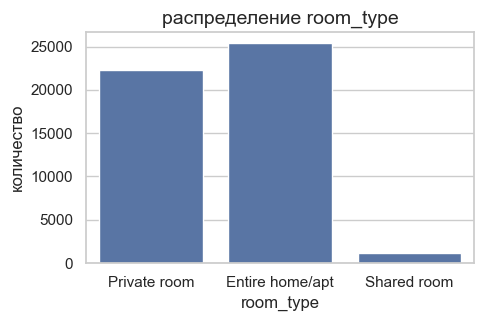

In [12]:
plt.figure(figsize=(5, 3))
sns.countplot(data=airbnb_dirty, x="room_type")

plt.title("распределение room_type", fontsize=14)
plt.xlabel("room_type", fontsize=12)
plt.ylabel("количество", fontsize=12)

plt.show()

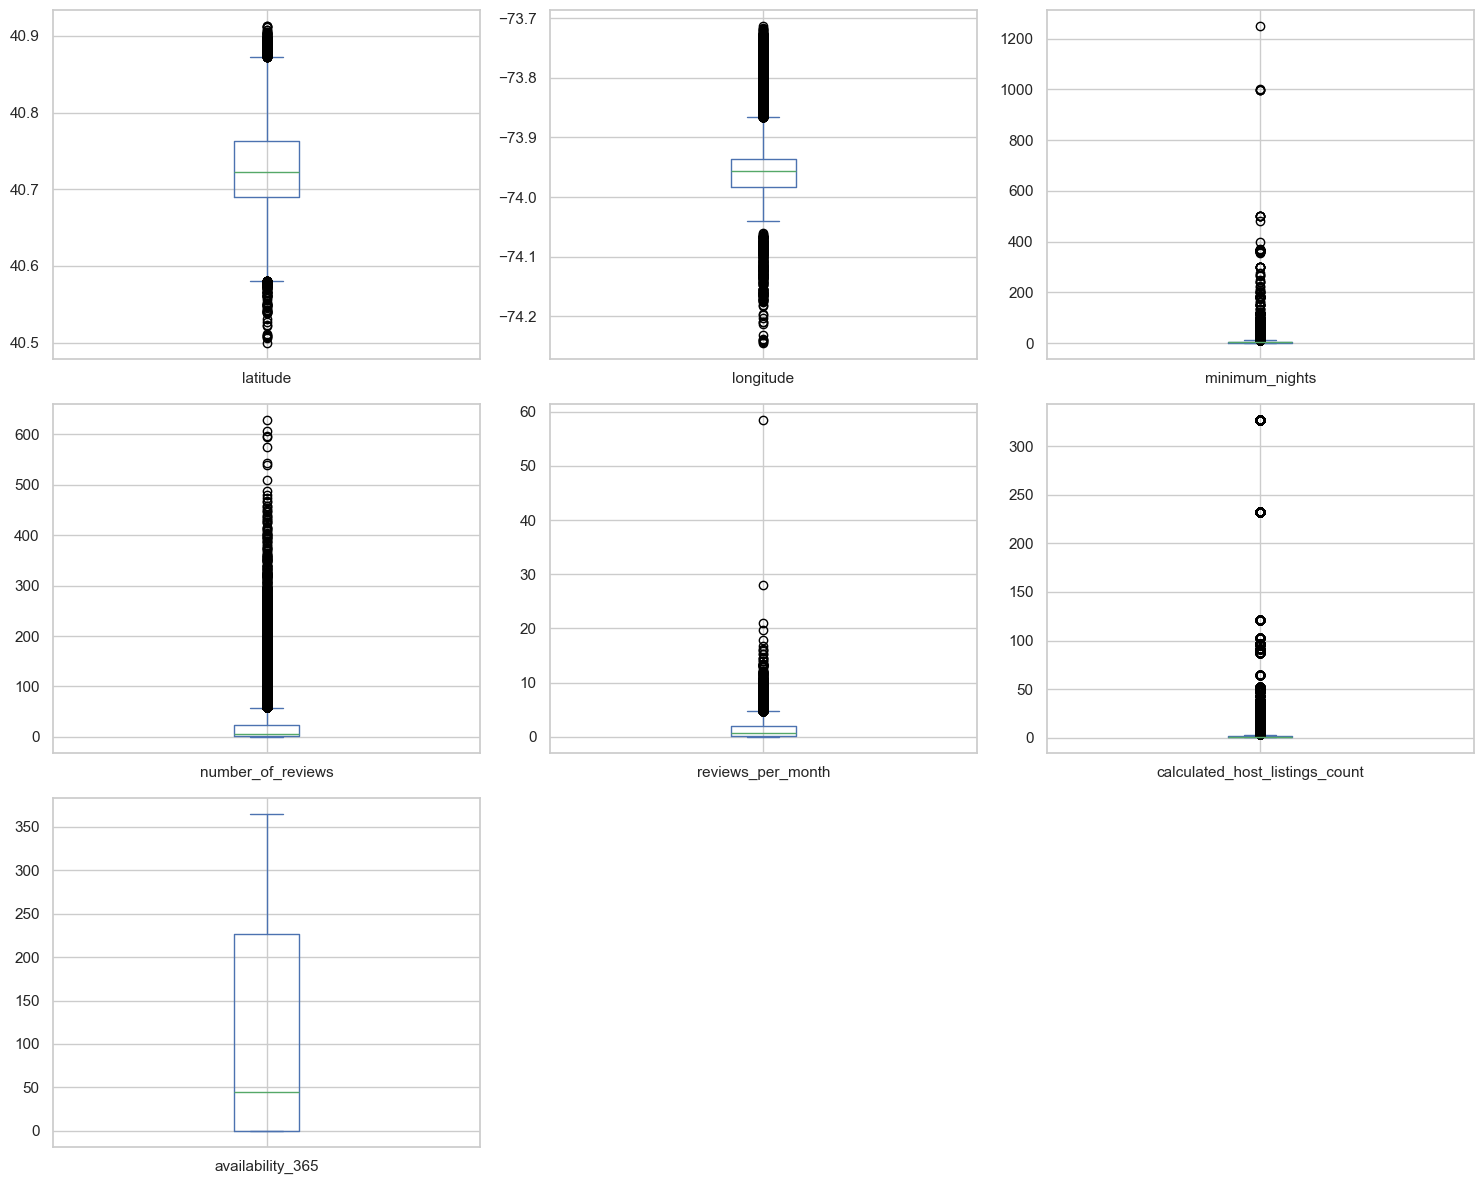

In [13]:
numeric_cols = airbnb_dirty.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(3, 3), figsize=(15, 12), sharey=False
)

plt.tight_layout()
plt.show()

### После EDA сформулируйте план чистки

Не пишите код сразу. Сначала словами:

- что сделаем с `price`;
- что сделаем с `name`;
- что сделаем с пропусками;
- что сделаем с экстремальными `minimum_nights`;
- какие новые признаки можно извлечь.

In [14]:
cleaning_plan = {
    "price": "Нужно написать regex, который бы убирал usd, $ и применял strip на строку price",
    "name": "приведу к нижнему регистру, оставлюв только буквы, цифры и знаки препинания",
    "missing_values": "last_review заполню never, reviews_per_month = 0 там, где last_review==NaN (мало ли где-то ошибка, и last_review имеет какое-то значение, а reviews_per_month - нет, и наоборот), в отсутствующих host_name поставлю пустую строку, для надёжности приведу к нижнему регистру",
    "outliers": "заполню выбросы minimum_nights значениями 365",
    "new_features": [
        "no_reviews/few_reviews",
        "one-hot encoding для room_type",
        "one-hot encoding для neighbour_group"
    ],
}

cleaning_plan

{'price': 'Нужно написать regex, который бы убирал usd, $ и применял strip на строку price',
 'name': 'приведу к нижнему регистру, оставлюв только буквы, цифры и знаки препинания',
 'missing_values': 'last_review заполню never, reviews_per_month = 0 там, где last_review==NaN (мало ли где-то ошибка, и last_review имеет какое-то значение, а reviews_per_month - нет, и наоборот), в отсутствующих host_name поставлю пустую строку, для надёжности приведу к нижнему регистру',
 'outliers': 'заполню выбросы minimum_nights значениями 365',
 'new_features': ['no_reviews/few_reviews',
  'one-hot encoding для room_type',
  'one-hot encoding для neighbour_group']}

In [15]:
# TODO 4. Очистите данные.
# Идеи, которые можно использовать:
# 1. price -> превратить в float
# 2. name -> заполнить пропуски пустой строкой
# 3. reviews_per_month -> заполнить нулями
# 4. last_review_missing -> бинарный признак пропуска
# 5. minimum_nights_clipped -> ограничить сверху, например p99 или 45
# 6. minimum_nights_log -> взять log1p
# 7. name_len, caps_ratio, has_exclamation -> простые текстовые признаки
# 8. is_entire_home -> бинарная цель для логистической регрессии

# Заготовки функций, если хотите:
# def clean_price_series(series):
#     cleaned = series.astype(str).str.replace(r'[^0-9.]', '', regex=True)
#     cleaned = cleaned.replace('', np.nan)
#     return pd.to_numeric(cleaned, errors='coerce')
#
# def caps_ratio(text):
#     letters = [ch for ch in str(text) if ch.isalpha()]
#     if not letters:
#         return 0.0
#     return sum(ch.isupper() for ch in letters) / len(letters)

airbnb_imp = airbnb_dirty.copy()

In [16]:
airbnb_imp["price"] = (airbnb_imp["price"]
                       .astype(str)
                       .str.lower()
                       .str.replace('$', '')
                       .str.replace('usd', '')
                       .str.replace(',', '')
                       .str.strip()
                       .astype(float))
# убираем $ usd и запятые, означающие тысячи

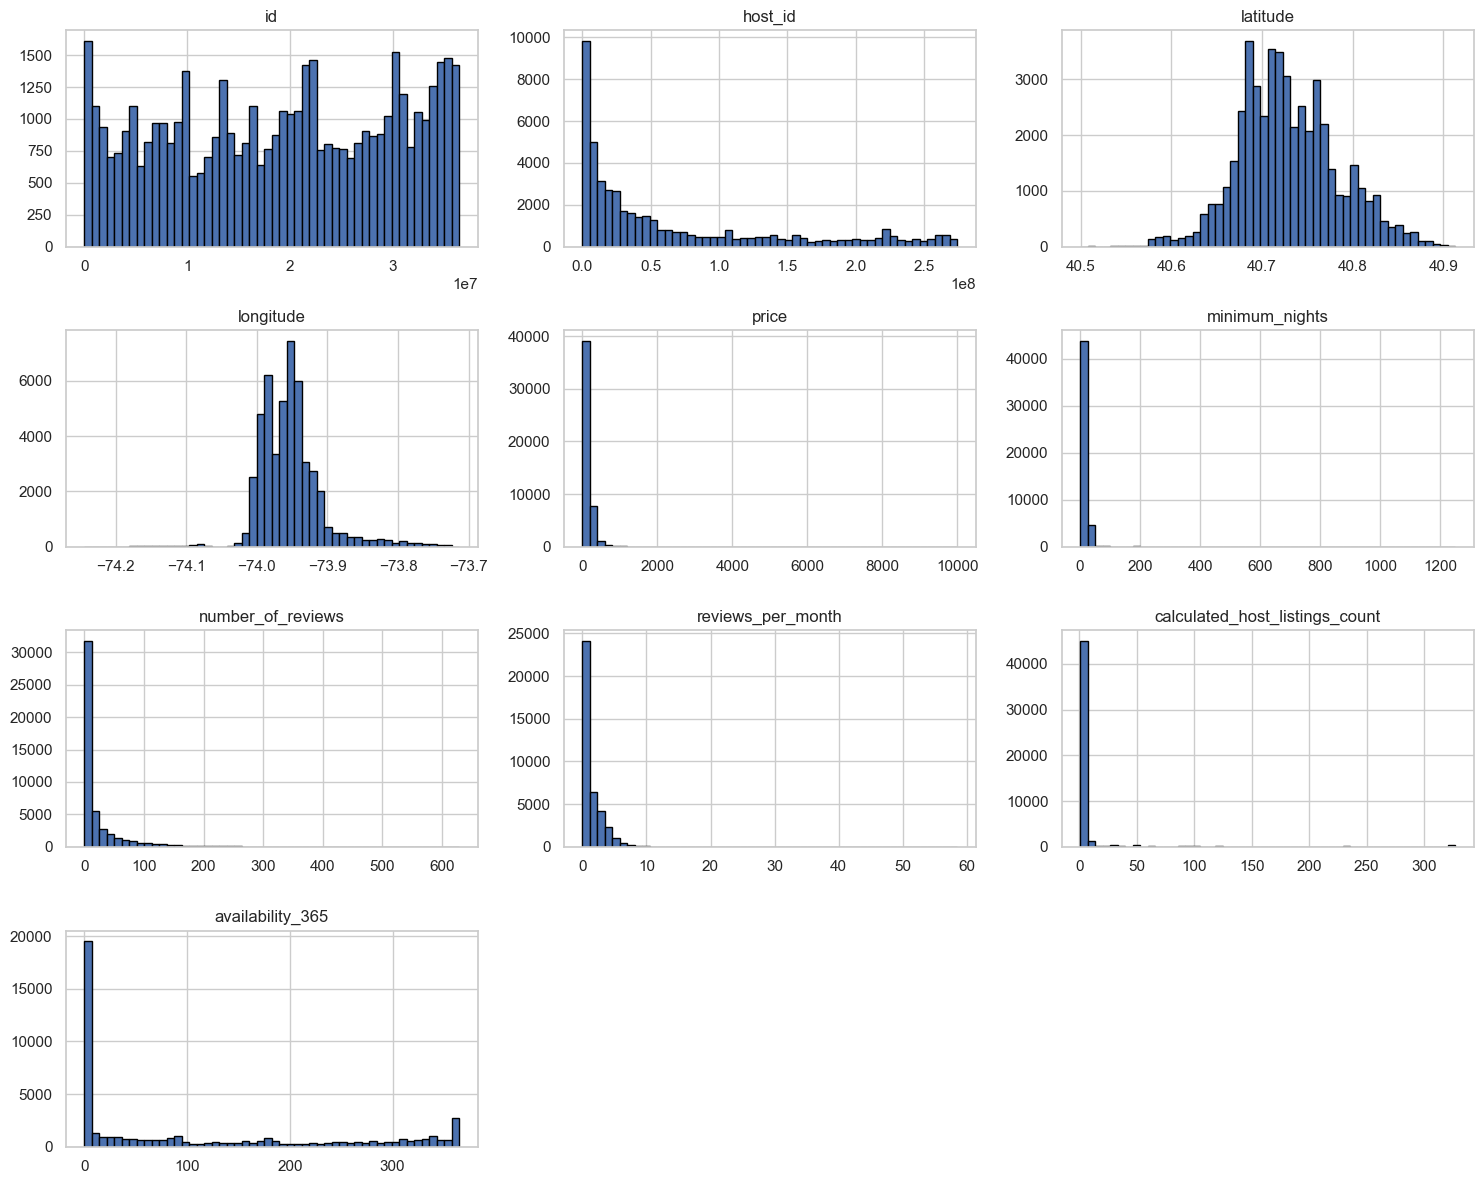

In [17]:
airbnb_imp.hist(figsize=(15, 12), bins=50, edgecolor="black")

plt.tight_layout()
plt.show()

In [18]:
# заполняем пропуски host_name
airbnb_imp["host_name"] = airbnb_imp["host_name"].fillna("").astype(str).str.lower()

# чистим отзывы от мусора, приводим к простому виду
pattern_for_name = r"[^a-zа-я0-9\s\.\,\!\?\;\:\(\)\'\"\-\|]"
airbnb_imp["name"] = (airbnb_imp["name"]
                      .astype(str)
                      .str.lower()
                      .str.replace(pattern_for_name, '', regex=True)
                      .str.strip())


# проверка вдруг где-то не совпадают пропущенные last_review и reviews_per_month
last_review_nan_equals_reviews_per_month_nan = airbnb_imp["last_review"][airbnb_imp["reviews_per_month"].isna()]
if len(last_review_nan_equals_reviews_per_month_nan) == len(airbnb_imp[airbnb_imp["last_review"].isna()]) == len(airbnb_imp[airbnb_imp["reviews_per_month"].isna()]):
    print("hell yeah")
    airbnb_imp["last_review"] = airbnb_imp["last_review"].fillna("never")
    airbnb_imp["reviews_per_month"] = airbnb_imp["reviews_per_month"].fillna(0)

# ограничиваем minimum_nights 365 днями
airbnb_imp["minimum_nights"] = airbnb_imp["minimum_nights"].clip(upper=365)

hell yeah


In [19]:
# проверка на пропуски
missing = airbnb_imp.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [20]:
airbnb_imp[
    ["host_name", "name", "price", "minimum_nights", "last_review", "reviews_per_month"]
].sample(8, random_state=42)

,host_name,name,price,minimum_nights,last_review,reviews_per_month
879,jane,come and go as you please in bkln!,89.0,3,2019-01-02,0.71
44383,giancarlo,"spacious, sunny room in queensbrooklyn",30.0,21,never,0.00
15394,alejandro,private bedroom in high-ceiling 4br apartment!,120.0,2,2017-04-28,0.43
43230,sonder (nyc),sonder | stock exchange | stunning 3br kitche...,470.0,2,2019-06-02,1.88
16332,gingie,spacious 2 bedroom with balcony!!!,199.0,2,2019-06-03,0.80
5966,amanda,entire 2br apt (not a railroad),170.0,1,2019-06-22,3.05
29838,hugo,1br in spacious 2 br in the heart of williamsb...,90.0,5,2018-02-21,0.06
41764,jing,comfortable place to live,60.0,30,never,0.00


## Блок 3. Линейная регрессия на Airbnb: цена

Теперь идем по той же логике, что и в основном ноуте.

### Что важно сделать честно

1. Сначала сравнить с `Mean baseline`.
2. Потом попробовать простую линейную регрессию.
3. Потом добавить feature engineering.
4. Если хочется углубиться, можно посчитать OLS руками через формулу из лекции.

In [21]:
# с учётом, что мы уже заполнили пропуски
regression_hypotheses = {
    "target": "price (обрежем после train_test_split)",
    "baseline_features": ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"],
    "improved_features": ["one-hot endoding для neighbourhood_group", "one-hot endoding для room_type", "calculated_host_listings_count", "last_review"],
    "which_metric_is_most_important": "MAE, потому что у неё нет супер большой чувствительности к выбросам (которых тут ну очень много, и даже если их сделать меньше, всё равно скорее всего останутся большие значения). Если после радиклаьной чистки я буду уверен, что в данных нет сильных выбросов, я буду использовать RMSE, потому что она более жёсткая и точная",
}

regression_hypotheses

{'target': 'price (обрежем после train_test_split)',
 'baseline_features': ['latitude',
  'longitude',
  'minimum_nights',
  'number_of_reviews',
  'reviews_per_month',
  'calculated_host_listings_count',
  'availability_365'],
 'improved_features': ['one-hot endoding для neighbourhood_group',
  'one-hot endoding для room_type',
  'calculated_host_listings_count',
  'last_review'],
 'which_metric_is_most_important': 'MAE, потому что у неё нет супер большой чувствительности к выбросам (которых тут ну очень много, и даже если их сделать меньше, всё равно скорее всего останутся большие значения). Если после радиклаьной чистки я буду уверен, что в данных нет сильных выбросов, я буду использовать RMSE, потому что она более жёсткая и точная'}

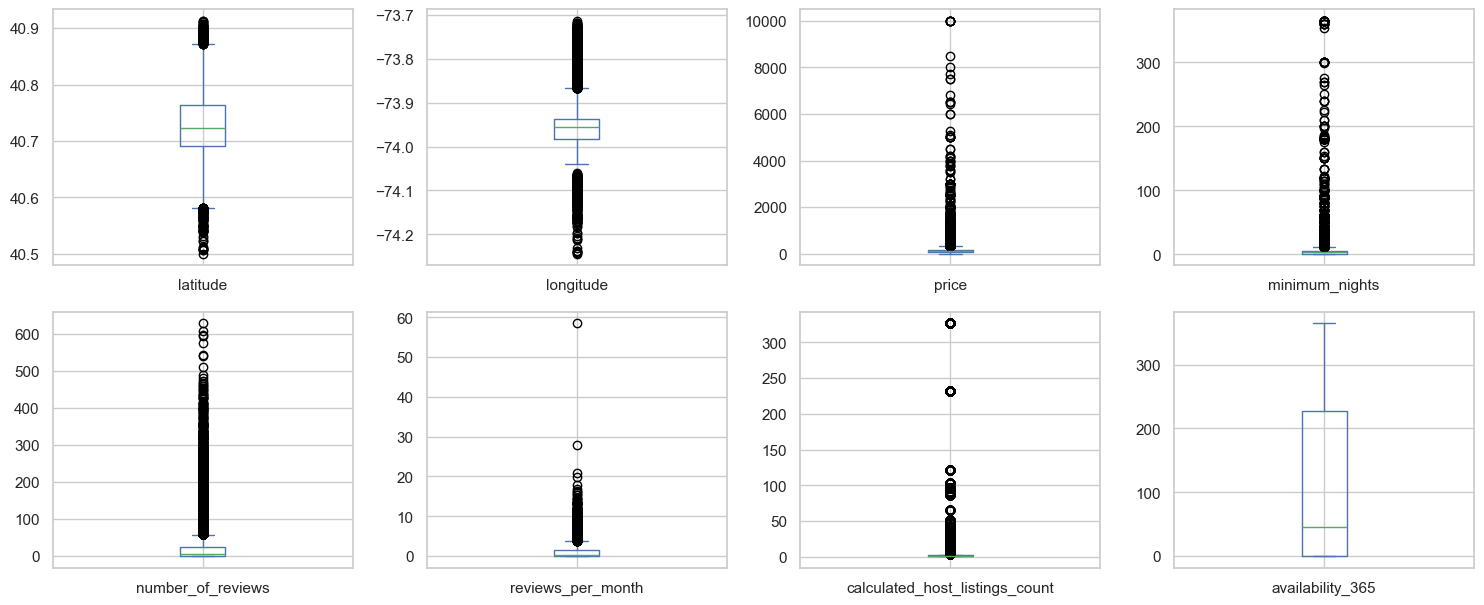

In [22]:
numeric_cols = airbnb_imp.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(4, 4), figsize=(15, 12), sharey=False
)

plt.tight_layout()
plt.show()

In [23]:
# сделал one-hot encoding, потому что модель не обрабатывает строки
airbnb_imp = pd.get_dummies(
    airbnb_imp,
    columns=["neighbourhood_group"],
    drop_first=True,  # если оставить первый столбец, линейной регрессии будет грустненько, потому что она будет думать, что строчки one-hot encoding зависимы друг от друга
    dtype=int,  # чтобы получились числа 0 и 1, а не були
)

In [24]:
airbnb_imp["price_log"] = np.log1p(airbnb_imp["price"])

airbnb_without_nan = airbnb_imp.copy() # для классификации в 4 блоке. это всё ещё грязный датасет, но у него есть price_log и отсутствувют выбросы
airbnb_imp = airbnb_imp.drop("price", axis=1)

In [25]:
airbnb_imp = pd.get_dummies(
    airbnb_imp,
    columns=["room_type"],
    drop_first=True,
    dtype=int,
)

In [26]:
airbnb_imp.describe()

,id,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,price_log,room_type_Private room,room_type_Shared room
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,6.942980,23.274466,1.090910,7.143982,112.781327,0.411167,0.443011,0.115881,0.007629,4.736885,0.456611,0.023724
std,1.098311e+07,7.861097e+07,0.054530,0.046157,17.530294,44.550582,1.597283,32.952519,131.622289,0.492050,0.496747,0.320085,0.087009,0.695344,0.498119,0.152190
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,1.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.248495,0.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,3.000000,5.000000,0.370000,1.000000,45.000000,0.000000,0.000000,0.000000,0.000000,4.672829,0.000000,0.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,5.000000,24.000000,1.580000,2.000000,227.000000,1.000000,1.000000,0.000000,0.000000,5.170484,1.000000,0.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,365.000000,629.000000,58.500000,327.000000,365.000000,1.000000,1.000000,1.000000,1.000000,9.210440,1.000000,1.000000


In [27]:
airbnb_imp[airbnb_imp["calculated_host_listings_count"] > 200]
# есть выбросы в calculated_host_listings_count. несмотря на количество объявлений, большая часть из них не имеет отзывов, поэтому можно удалить объявления без отзывов (логично, что если нет отзывов, значит туда либо никто не ездит из-за цены/качества, либо просто потмоу что цена абсурдно большая)
airbnb_imp = airbnb_imp[(airbnb_imp["last_review"] != "never") | (airbnb_imp["calculated_host_listings_count"] <= 200)]

In [28]:
# заметил, что есть значения с availability_365==0. обнаружил, что это почти половина датасета, а там, где нет отзывов - 4845 строк, что очень много (10 процентов). не буду трогать
airbnb_imp[(airbnb_imp["availability_365"] == 0) & (airbnb_imp["last_review"] == 'never')]
# airbnb_imp = airbnb_imp[(airbnb_imp["availability_365"] != 0) | (airbnb_imp["last_review"] != 'never')]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,price_log,room_type_Private room,room_type_Shared room
26,8700,magnifique suite au n de manhattan - vue cloitres,26394,claude & sophie,Inwood,40.86754,-73.92639,4,0,never,0.0,1,0,0,1,0,0,4.394449,1,0
193,51438,1 bedroom in 2 bdrm apt- upper east,236421,jessica,Upper East Side,40.77333,-73.95199,14,0,never,0.0,2,0,0,1,0,0,4.875197,1,0
267,64015,prime east village 1 bedroom,146944,david,East Village,40.72807,-73.98594,3,0,never,0.0,1,0,0,1,0,0,5.303305,0,0
276,65556,"room in s3rdbedford, williamsburg!!!",320422,marlon,Williamsburg,40.71368,-73.96260,3,0,never,0.0,1,0,1,0,0,0,4.110874,1,0
390,118680,spacious east village apt near it all!!!,599354,bobby,East Village,40.73067,-73.98702,2,0,never,0.0,1,0,0,1,0,0,4.477337,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48550,36313048,sunny room with private entrance in shared home,16883913,tiffany,Ridgewood,40.69919,-73.89902,1,0,never,0.0,1,0,0,0,1,0,3.828641,1,0
48731,36410519,sunlight charming apt. in the heart of brooklyn,121384174,luciana paula,Park Slope,40.66716,-73.98101,8,0,never,0.0,1,0,1,0,0,0,4.718499,0,0
48756,36419441,murray hill masterpiece!!!,273824202,david,Murray Hill,40.74404,-73.97239,2,0,never,0.0,1,0,0,1,0,0,4.867534,0,0
48760,36420725,"sunnyside, queens 15 mins to midtown clean comfy",19990280,brandon,Sunnyside,40.74719,-73.91919,1,0,never,0.0,1,0,0,0,1,0,3.850148,1,0


In [29]:
# TODO 5. Сделайте baseline для регрессии.
# План:
# 1. выбрать target, например price_capped
# 2. сделать train/test split
# 3. сравнить Mean baseline и sklearn LinearRegression
# 4. посчитать R2, MAE, RMSE, NRMSE, MAPE_%

# Подсказка:
# y_mean_pred = np.repeat(y_train.mean(), len(y_test))
# regression_metrics(y_test, y_mean_pred)
# regression_metrics(y_test, model.predict(X_test))

target = "price_log"
cols_to_drop = [
    target,
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review",
    "neighbourhood",
]
X = airbnb_imp.drop(columns=cols_to_drop)
y = airbnb_imp[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# mean baseline
y_mean_pred = np.repeat(y_train.mean(), len(y_test))
print("mean baseline:", regression_metrics(y_test, y_mean_pred))

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("LinearRegression:", regression_metrics(y_test, model.predict(X_test)))
print("MAE exp: ", mae_manual(np.expm1(y_test), np.expm1(y_pred)))
# 60.60797483004566

mean baseline: {'R2': np.float64(-7.364496930950537e-05), 'MAE': np.float64(0.546357525257602), 'RMSE': np.float64(0.6911861239180692), 'NRMSE': np.float64(1.000036821806732), 'MAPE_%': np.float64(11.75533435792907)}
LinearRegression: {'R2': np.float64(0.48523107744644445), 'MAE': np.float64(0.3591649171298073), 'RMSE': np.float64(0.4958898047842168), 'NRMSE': np.float64(0.717473987370661), 'MAPE_%': np.float64(7.558532663874982)}
MAE exp:  60.60797483004566


In [30]:
# TODO 6. Добавьте feature engineering и сравните качество.
# Идеи признаков:
# - neighbourhood_group
# - room_type
# - latitude, longitude
# - minimum_nights_clipped, minimum_nights_log
# - name_len, caps_ratio, has_exclamation
# - last_review_missing

# Подсказка:
# X_improved = pd.get_dummies(..., drop_first=True)


In [31]:
airbnb_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48571 entries, 0 to 48894
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 48571 non-null  int64  
 1   name                               48571 non-null  object 
 2   host_id                            48571 non-null  int64  
 3   host_name                          48571 non-null  object 
 4   neighbourhood                      48571 non-null  object 
 5   latitude                           48571 non-null  float64
 6   longitude                          48571 non-null  float64
 7   minimum_nights                     48571 non-null  int64  
 8   number_of_reviews                  48571 non-null  int64  
 9   last_review                        48571 non-null  object 
 10  reviews_per_month                  48571 non-null  float64
 11  calculated_host_listings_count     48571 non-null  int64  


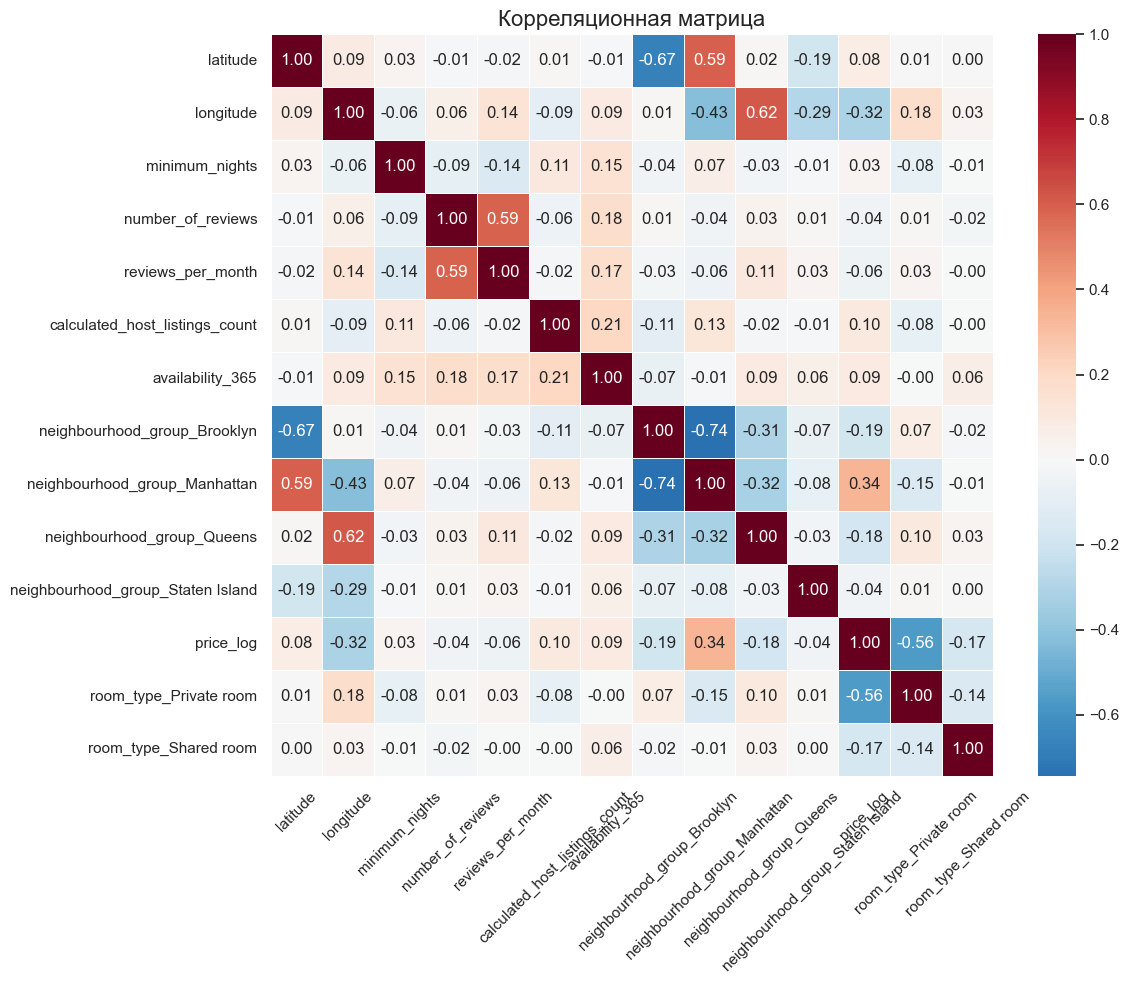

In [32]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    airbnb_imp.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review', 'neighbourhood']).corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Корреляционная матрица', fontsize=16)
plt.xticks(rotation=45) # поворот подписей 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

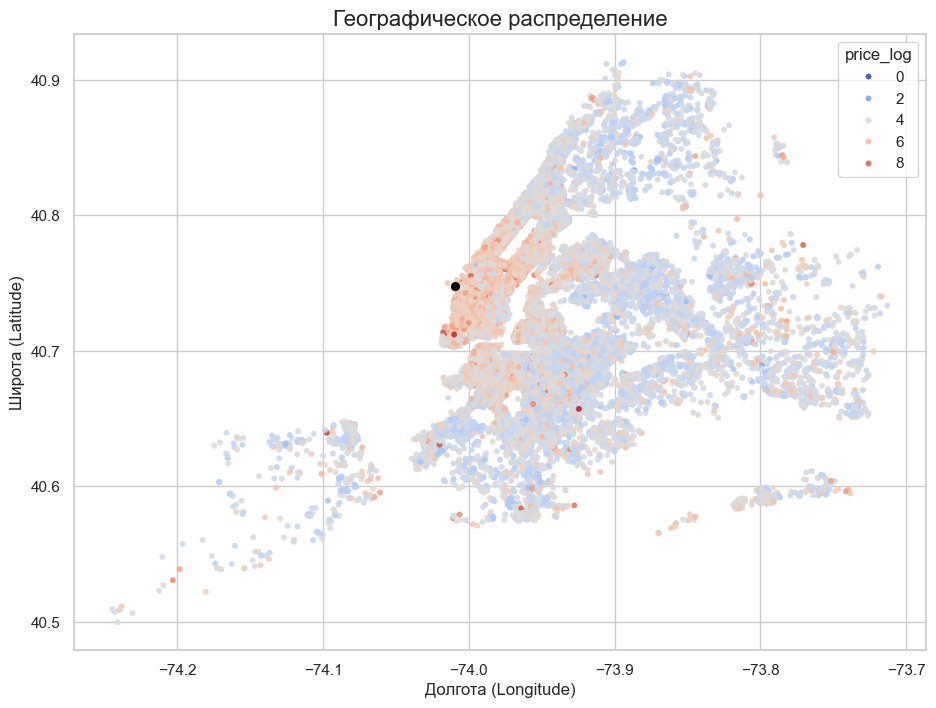

In [33]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=airbnb_imp, 
    x='longitude', 
    y='latitude', 
    hue='price_log', # раскрашиваем по столбцу с ценой
    palette='coolwarm',
    alpha=0.9, 
    s=15,
    edgecolor=None
)

ESB_latitude = 40.7476406
ESB_longitude = -74.0097132
# отметил черным empire state building
plt.scatter(x=ESB_longitude, y=ESB_latitude, color='black', s=30)

plt.title('Географическое распределение', fontsize=16)
plt.xlabel('Долгота (Longitude)')
plt.ylabel('Широта (Latitude)')
plt.show()

In [34]:
# самый дорогой район - около Эмпайр-стейт-билдинг. сделаем его "центром притяжения" и будем измерять расстояние до него, потому что по графику видно, что чем ближе к нему, тем больше цена. используем не просто теорему пифагора, а формулу гаверсинуса, которая вычисляет точное расстояние

# airbnb_imp["distance_to_ESB"] = ((ESB_longitude - airbnb_imp['longitude']) ** 2 + (ESB_latitude - airbnb_imp['latitude']) ** 2) ** 0.5

lat1, lon1 = np.radians(ESB_latitude), np.radians(ESB_longitude)
lat2, lon2 = np.radians(airbnb_imp["latitude"]), np.radians(airbnb_imp["longitude"])

dlon = lon2 - lon1
dlat = lat2 - lat1

# применяем формулу гаверсинуса
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
c = 2 * np.arcsin(np.sqrt(a))

earth_radius = 6371

airbnb_imp["distance_to_ESB_km"] = c * earth_radius

In [35]:
X_imp = airbnb_imp.drop(columns=cols_to_drop)
y_imp = airbnb_imp[target]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.3, random_state=42
)

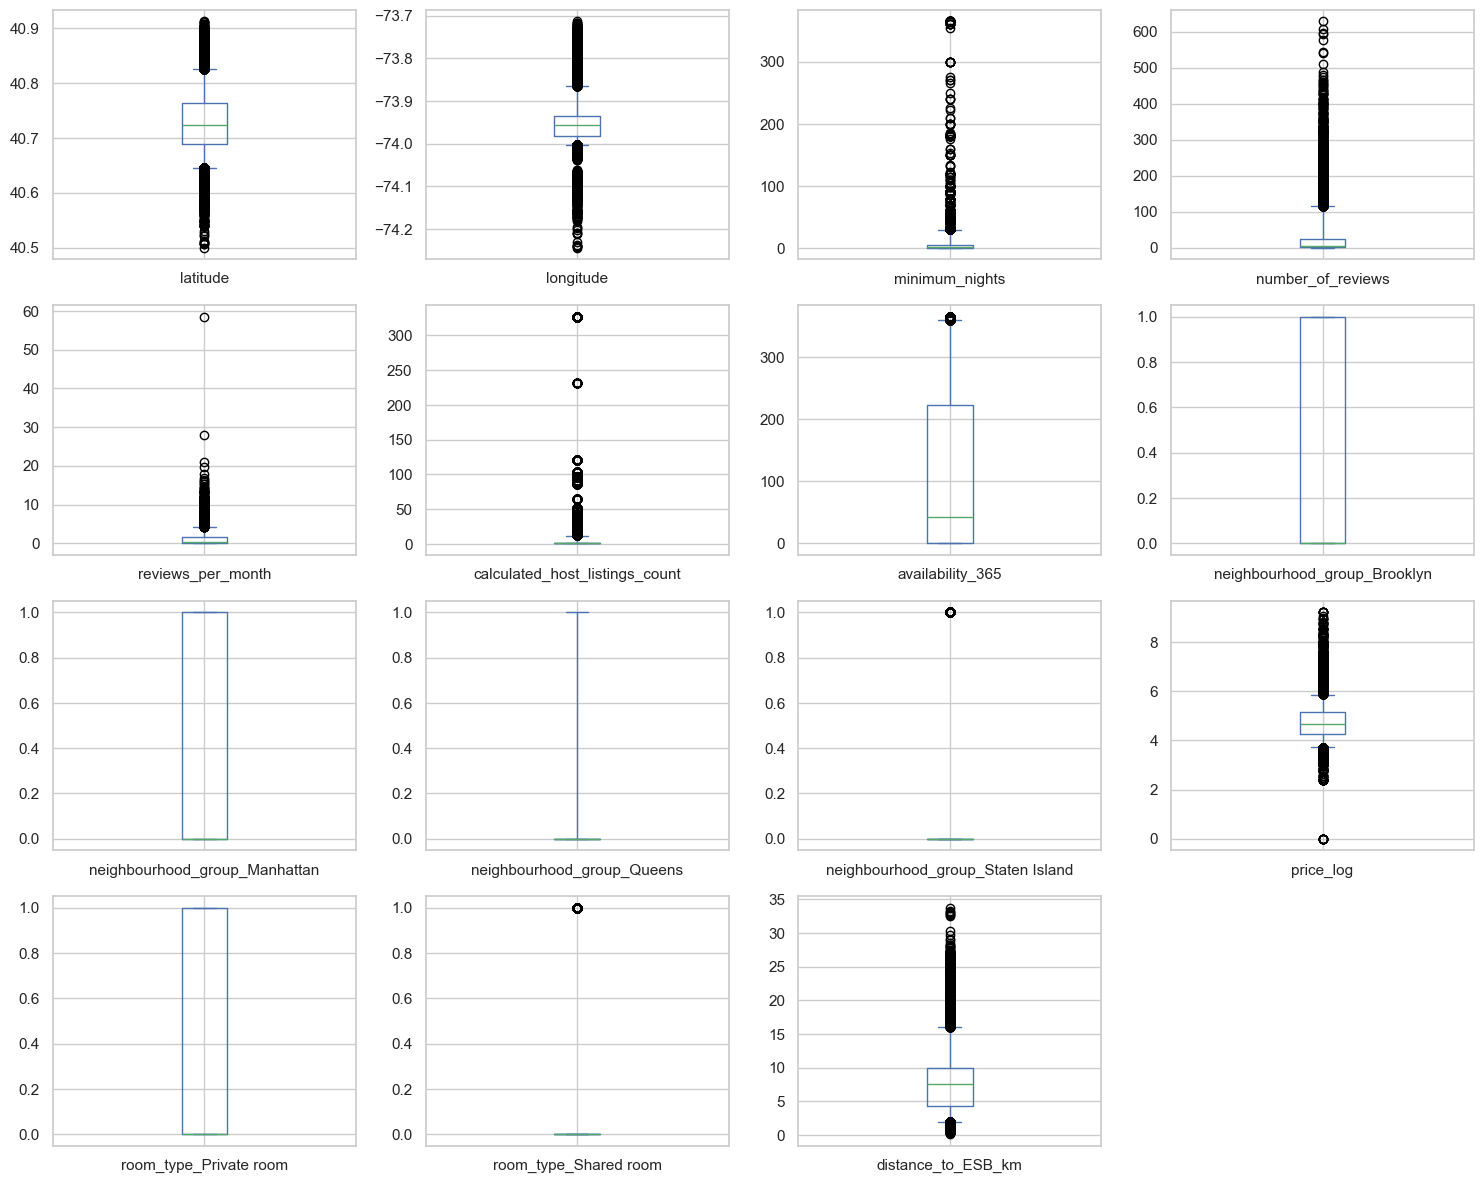

In [36]:
numeric_cols = airbnb_imp.select_dtypes(include=["int64", "float64"]).drop(columns=["id", "host_id"])

numeric_cols.plot(
    kind="box", subplots=True, layout=(4, 4), figsize=(15, 12), sharey=False, whis=[5, 95]
)

plt.tight_layout()
plt.show()

In [37]:
upper_price_limit = y_train_imp.quantile(0.99)
y_train_imp = y_train_imp.clip(upper=upper_price_limit)
y_test_imp = y_test_imp.clip(upper=upper_price_limit)

X_train_imp['no_reviews'] = (X_train_imp['number_of_reviews'] > 0).astype(int)
X_test_imp['no_reviews'] = (X_test_imp['number_of_reviews'] > 0).astype(int)

mean_host_listings_count = X_train_imp['calculated_host_listings_count'].quantile(0.95)
X_train_imp['popular_host'] = (X_train_imp['calculated_host_listings_count'] > mean_host_listings_count).astype(int)
X_test_imp['popular_host'] = (X_test_imp['calculated_host_listings_count'] > mean_host_listings_count).astype(int)

print(len(X_train_imp))
print(len(X_test_imp))


33999
14572


In [38]:
# TODO 7. Если хотите пойти глубже, реализуйте ручной OLS.
# Это прямое продолжение формулы из лекции:
# w* = (X^T X)^(-1) X^T y
#
# Подсказка:
# weights = manual_linear_weights(X_train, y_train)
# y_pred_manual = manual_linear_predict(X_test, weights)
# regression_metrics(y_test, y_pred_manual)
#
# Важно:
# - перед этим X должен быть только числовой
# - лучше сравнить ручной результат со sklearn на одной и той же матрице признаков

weights = manual_linear_weights(X_train_imp, y_train_imp)
y_pred_manual = manual_linear_predict(X_test_imp, weights)
regression_metrics(y_test_imp, y_pred_manual)

{'R2': np.float64(0.5306183532262869),
 'MAE': np.float64(0.34067777807588256),
 'RMSE': np.float64(0.46216533277240496),
 'NRMSE': np.float64(0.6851143311694137),
 'MAPE_%': np.float64(7.198400520104395)}

In [39]:
model = LinearRegression()
model.fit(X_train_imp, y_train_imp)

y_pred_imp = model.predict(X_test_imp)
print('LinearRegression:', regression_metrics(y_test_imp, model.predict(X_test_imp)))
print("MAE exp: ", mae_manual(np.expm1(y_test_imp), np.expm1(y_pred_imp)))
# 51.790052310669004

LinearRegression: {'R2': np.float64(0.5306183532731352), 'MAE': np.float64(0.3406777779031995), 'RMSE': np.float64(0.4621653327493409), 'NRMSE': np.float64(0.6851143311352235), 'MAPE_%': np.float64(7.198400514992111)}
MAE exp:  51.790052310669004


### Вопросы после регрессии

- Почему `R2` может быть скромным, а модель всё равно полезнее mean baseline?
- Чем `MAE` отличается от `RMSE` по смыслу?
- Почему `RMSE` особенно чувствительна к редким большим ошибкам?
- Почему на Airbnb вообще не стоит ждать идеально высокой линейной метрики?

In [40]:
# итого получилось снизить MAE с 61 доллара до 52, что весьма неплохой результат

In [ ]:
# 1. R2 показывает, какую долю разброса цен смогла объяснить модель. даже если он скромный, это означает, что модель нашла закономерности, которые лучше случайности. с точки зрения принятия решений эта модель уже приносит реальную пользу, в отличие от mean baseline, так как улавливает главный тренд (пока mean везде влепит 150 долларов, наша модель подумает и решит, что в одном месте будет 40, а в другом - 450)
# 2. MAE отвечает на вопрос: "на сколько долларов в среднем мы ошибаемся?", относится ко всем ошибкам равноценно. RMSE - метрика "катастрофичности", которая сильно снижается при больших ошибках.ииспользуется тогда, когда несколько мелких ошибок - это нормально, а одна огромная - это провал.
# 3. перед тем как усреднить значения и брать корень, каждая из ошибок возводится в квадрат, из-за чего сильно увеличиваются значения (например, при 10 ошибках в 5 долларов сумма квадратов ошибок будет всего 250, а при 1 ошибке в 50 будет 2500, что в 10 раз больше, хотя это всего одна ошибка)
# 4. ценообразование - сложная вещь (не опираясь на датасет). например, за наличие бассейна в Манхэттене будет наценка 40%, а в Staten Island - 5%, потому что сам район больше промышленнный, и в нём больше рек. возможно, для этого датасета больше бы подошло дерево решений (вроде как раз с помощью него можно было бы разбить на районы и удобно предсказывать внутри определённых районов)

## Блок 4. Классификация на Airbnb: тип жилья

Теперь меняем задачу.

### Бинарная цель

- `1` = `Entire home/apt`
- `0` = `Private room`

### Что важно сделать

1. Сравнить с majority baseline.
2. Проверить `LinearRegression + clip` как плохой классификатор.
3. Обучить `LogisticRegression`.
4. Если хочется углубиться, сделать ручную логистическую регрессию через сигмоиду.

In [42]:
classification_hypotheses = {
    "target": "is_entire_home",
    "useful_features": ["price_log", "distance_to_ESB_km", "minimum_nights", "number_of_reviews"],
    "why_logistic_is_more_natural": "линейная регрессия будет пытаться 'усреднить' значения, чтобы минимизировать ошибку. логистическая регрессия использует сигмоиду, которая плавно 'сжимает' любые ответы модели в диапазон от 0 до 1, превращая их в вероятности",
    "which_metric_is_most_important": "думаю, хорошо подойдёт roc_auc и f1",
}

classification_hypotheses

{'target': 'is_entire_home',
 'useful_features': ['price_log',
  'distance_to_ESB_km',
  'minimum_nights',
  'number_of_reviews'],
 'why_logistic_is_more_natural': "линейная регрессия будет пытаться 'усреднить' значения, чтобы минимизировать ошибку. логистическая регрессия использует сигмоиду, которая плавно 'сжимает' любые ответы модели в диапазон от 0 до 1, превращая их в вероятности",
 'which_metric_is_most_important': 'думаю, хорошо подойдёт roc_auc и f1'}

In [43]:
# TODO 8. Сделайте baseline для классификации.
# Шаги:
# 1. оставьте только Entire home/apt и Private room
# 2. соберите признаки
# 3. сделайте majority baseline
# 4. посчитайте Accuracy, Precision, Recall, F1, ROC_AUC, LogLoss

# Подсказка:
# majority_class = int(y_train.mean() >= 0.5)
# majority_prob = np.repeat(float(y_train.mean()), len(y_test))
# majority_pred = np.repeat(majority_class, len(y_test))
# classification_metrics(y_test, majority_prob, majority_pred)

airbnb_cls = airbnb_without_nan[airbnb_without_nan['room_type'].isin(['Entire home/apt', 'Private room'])].copy()
cols_to_drop_cls = cols_to_drop + ['room_type', 'is_entire_home']

# создаем бинарный таргет: 1 = Entire home/apt, 0 = Private room
airbnb_cls['is_entire_home'] = (airbnb_cls['room_type'] == 'Entire home/apt').astype(int)

X_cls = airbnb_cls.drop(columns=[col for col in cols_to_drop_cls if col in airbnb_cls.columns])
y_cls = airbnb_cls['is_entire_home']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42
)

majority_class = int(y_train_c.mean() >= 0.5)

majority_prob = np.repeat(float(y_train_c.mean()), len(y_test_c))
majority_pred = np.repeat(majority_class, len(y_test_c))

print(classification_metrics(y_test_c, majority_prob, majority_pred))

roc_auc_majority = roc_auc_score(y_test_c, majority_pred)
f1_majority = f1_manual(y_test_c, majority_pred)
print('roc_auc:', roc_auc_majority)
print('f1:', f1_majority)

{'Accuracy': np.float64(0.5283150617973605), 'Precision': np.float64(0.5283150617973605), 'Recall': np.float64(1.0), 'F1': np.float64(0.6913693059807191), 'ROC_AUC': 0.5, 'LogLoss': np.float64(0.6916076901205648)}
roc_auc: 0.5
f1: 0.6913693059807191


In [44]:
# TODO 9. Сравните LinearRegression + clip и LogisticRegression.
# Подсказка:
# 1. для LinearRegression получите сырые scores
# 2. потом prob = np.clip(scores, 0, 1)
# 3. pred = (prob >= 0.5).astype(int)
# 4. для LogisticRegression используйте predict_proba
# 5. сравните метрики не только между собой, но и с majority baseline

lin_cls_model = LinearRegression()
lin_cls_model.fit(X_train_c, y_train_c)

lin_scores = lin_cls_model.predict(X_test_c)

# обрезаем значения, чтобы имитировать вероятность
lin_prob = np.clip(lin_scores, 0, 1)

# превращаем вероятности в классы по порогу 0.5
lin_pred = (lin_prob >= 0.5).astype(int)

print("LinearRegression + clip")
print(classification_metrics(y_test_c, lin_prob, lin_pred))

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

log_prob = log_model.predict_proba(X_test_c)[:, 1]

log_pred = log_model.predict(X_test_c)

print("LogisticRegression")
print(classification_metrics(y_test_c, log_prob, log_pred))

roc_auc_scores = sorted(
    (("baseline", roc_auc_majority),
    ("LinearRegression + clip", roc_auc_score(y_test_c, lin_prob)),
    ("LogisticRegression", roc_auc_score(y_test_c, log_prob))),
    key=lambda x: x[1],
    reverse=True
)
print("ROC_AUC: ", roc_auc_scores)

f1_scores = sorted(
    (("baseline", f1_majority),
    ("LinearRegression + clip", f1_manual(y_test_c, lin_pred)),
    ("LogisticRegression", f1_manual(y_test_c, log_pred))),
    key=lambda x: x[1],
    reverse=True
)
print("F1: ", f1_scores)

LinearRegression + clip
{'Accuracy': np.float64(0.6679701138188674), 'Precision': np.float64(0.6904213521203089), 'Recall': np.float64(0.6735395189003437), 'F1': np.float64(0.6818759617314512), 'ROC_AUC': 0.729137715906585, 'LogLoss': np.float64(0.6437889854320784)}
LogisticRegression
{'Accuracy': np.float64(0.8169820543258153), 'Precision': np.float64(0.8628026412325752), 'Recall': np.float64(0.7771609833465504), 'F1': np.float64(0.8177456366038522), 'ROC_AUC': 0.8952265706979664, 'LogLoss': np.float64(0.492369029149845)}
ROC_AUC:  [('LogisticRegression', 0.8952235966230945), ('LinearRegression + clip', 0.729137715906585), ('baseline', 0.5)]
F1:  [('LogisticRegression', np.float64(0.8177456366038522)), ('baseline', np.float64(0.6913693059807191)), ('LinearRegression + clip', np.float64(0.6818759617314512))]


In [45]:
# TODO 10. Если хотите пойти глубже, реализуйте ручную логистическую регрессию.
# Это прямое продолжение лекции:
# p(x) = sigmoid(w^T x)
# log-loss = -mean(y log p + (1-y) log(1-p))
#
# Подсказка:
# 1. возьмите маленький набор числовых признаков
# 2. стандартизируйте train/test
# 3. weights, history = fit_logistic_manual(X_train_std, y_train, lr=0.2, steps=1200)
# 4. prob = predict_logistic_manual(X_test_std, weights)
# 5. pred = (prob >= 0.5).astype(int)
# 6. classification_metrics(y_test, prob, pred)

# Ваш код здесь

In [46]:
classification_metrics(y_test_c, log_prob, log_pred)

{'Accuracy': np.float64(0.8169820543258153),
 'Precision': np.float64(0.8628026412325752),
 'Recall': np.float64(0.7771609833465504),
 'F1': np.float64(0.8177456366038522),
 'ROC_AUC': 0.8952265706979664,
 'LogLoss': np.float64(0.492369029149845)}

In [47]:
# заметно значительное превосходство модели sklearn над нашей по нескольким причинам: 
# 1. в sklearn.LogisticRegression по умолчанию включено L2 регуляризация, которая помогает бороться с мультиколлинеарностью
# 2. в sklearn используются продвинутый метод нахождения весов lbfgs, который, в отличие от нашего градиентного спуска, учитывает вторую производную при расчёте того, насколько далеко нужно "перескачить", благодаря чему лучше и быстрее находит веса
# информацию брал с сайта scikit-learn про логистическую регрессию
weights_log, history_log = fit_logistic_manual(X_train_c, y_train_c, lr=0.2, steps=1000)
prob_manual_log = predict_logistic_manual(X_test_c, weights_log)
log_manual_pred = (prob_manual_log >= 0.5).astype(int)
classification_metrics(pred=log_manual_pred, y_true=y_test_c, prob=prob_manual_log)

{'Accuracy': np.float64(0.6732770057956846),
 'Precision': np.float64(0.901083634342873),
 'Recall': np.float64(0.42862807295796984),
 'F1': np.float64(0.5809225257501119),
 'ROC_AUC': 0.6903614635813771,
 'LogLoss': np.float64(4.490315220993724)}

### Вопросы после классификации

- Почему `Accuracy` не всегда достаточно?
- Когда важнее `Precision`, а когда `Recall`?
- Почему `LogLoss` может быть содержательнее, чем просто доля угаданных классов?
- Если `LinearRegression + clip` не сильно хуже по `Accuracy`, почему мы всё равно говорим, что логистическая регрессия здесь естественнее?

In [48]:
# 1. accuracy врет при дисбалансе классов, если модель предсказывает только превосходящий по количеству класс
# 2. precision - когда ложная тревога дорого стоит, recall - когда критично не пропустить событие
# 3. logloss оценивает не только сам класс, но и уверенность в нем, сильно штрафуя за уверенную ошибку
# 4. ЛР математически создана для вероятностей [0, 1] и оптимизирует logloss, а линейная строит бесконечную прямую под mse, лишь пытаясь прямой линией описать нелинейные данные

## Блок 5. Свои идеи

Теперь можно предлагать собственные улучшения.

Хорошие направления:

- взять `log(price)` вместо `price_capped`;
- попробовать новые текстовые признаки;
- сильнее ограничить выбросы;
- оставить только крупные районы;
- попробовать другие наборы признаков для ручной логистической регрессии;
- сравнивать новые идеи не только с лучшей моделью, но и с baseline.

In [49]:
student_experiment = {
    "idea": "",
    "why_it_should_help": "",
    "which_metric_should_improve": "",
    "result": "",
}

student_experiment

{'idea': '',
 'why_it_should_help': '',
 'which_metric_should_improve': '',
 'result': ''}

In [ ]:
# TODO 11. Песочница для вашей идеи.
# Совет:
# 1. сначала напишите гипотезу словами выше
# 2. потом укажите, по какой метрике ждете улучшение
# 3. только потом пишите код

# я попробую использовать улучшенную выборку из линейной регрессии, жду небольшое улучшение метрики ROC_AUC (так как модель будет увереннее в вероятностях) и существенного улучшения accuracy и f1 по сравнению с прошлым результатом

airbnb_cls_best = airbnb_imp.copy()
airbnb_cls_best["is_entire_home"] = (
    airbnb_cls_best["room_type_Private room"]
    == airbnb_cls_best["room_type_Shared room"]
).astype(int)

cols_to_drop_best = [
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review",
    "neighbourhood",
    "room_type",
    "is_entire_home",
    "room_type_Private room",
    "room_type_Shared room"
]

X_best = airbnb_cls_best.drop(
    columns=[col for col in cols_to_drop_best if col in airbnb_cls_best.columns]
)
y_best = airbnb_cls_best["is_entire_home"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_best, y_best, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_b)
X_test_scaled = scaler.transform(X_test_b)

log_model_best = LogisticRegression(max_iter=1000)
log_model_best.fit(X_train_scaled, y_train_b)

log_prob_best = log_model_best.predict_proba(X_test_scaled)[:, 1]
log_pred_best = log_model_best.predict(X_test_scaled)

print(classification_metrics(y_test_b, log_prob_best, log_pred_best))

{'Accuracy': np.float64(0.8423003019489432), 'Precision': np.float64(0.8473922299095263), 'Recall': np.float64(0.8469414893617021), 'F1': np.float64(0.8471667996807661), 'ROC_AUC': 0.9050956194711625, 'LogLoss': np.float64(0.4154023207200085)}


## Финальная рефлексия

Заполните коротко, но честно. Это важнее, чем просто много кода.

In [51]:
final_reflection = {
    "what_helped_in_eda_the_most": "боксплот, вдумчивый анализ признаков, применение какой-то нативной логики(как с дистанцией до ESB) и подручные методы по типу describe, настройка усов у боксплотов через whis=[5, 95]",
    "which_regression_metric_was_most_informative": "mae, так как она показывает ошибку в понятных единицах",
    "which_classification_metric_was_most_informative": "ROC_AUC наверное, не могу точно сказать почему, потому что насмотренности не очень много пока, но предполагаю, что она наиболее четко бы описала то, что реально у меня получилось (например для baseline она была 0.5, что означало простую случайность, а по мере улучшения модели она росла постепенно)",
    "where_linear_regression_was_natural": "предсказание price",
    "why_logistic_regression_was_more_natural_for_binary_target": "логистическая регрессия будет пытаться подстроить прямую линию под нелинейные данные, а сигмоида искривится, выдавая вероятность. ЛинРегр имеет бесконечный график и может выдавать вероятности не принадлежащие [0; 1]. ЛинРегр сильно реагирует на выбросы, в отличие от сигмоиды, которая благодаря логлосс почти забивает на выбросы",
    "which_formula_from_the_lecture_became_clearer_after_code": "w* = (X^T X)^(-1) X^T y",
}

final_reflection

{'what_helped_in_eda_the_most': 'боксплот, вдумчивый анализ признаков, применение какой-то нативной логики(как с дистанцией до ESB) и подручные методы по типу describe, настройка усов у боксплотов через whis=[5, 95]',
 'which_regression_metric_was_most_informative': 'mae, так как она показывает ошибку в понятных единицах',
 'which_classification_metric_was_most_informative': 'ROC_AUC наверное, не могу точно сказать почему, потому что насмотренности не очень много пока, но предполагаю, что она наиболее четко бы описала то, что реально у меня получилось (например для baseline она была 0.5, что означало простую случайность, а по мере улучшения модели она росла постепенно)',
 'where_linear_regression_was_natural': 'предсказание price',
 'why_logistic_regression_was_more_natural_for_binary_target': 'логистическая регрессия будет пытаться подстроить прямую линию под нелинейные данные, а сигмоида искривится, выдавая вероятность. ЛинРегр имеет бесконечный график и может выдавать вероятности не

In [52]:
from sklearn.metrics import confusion_matrix, auc
y_prob = log_prob_best
y_true = y_test_b
fpr_list = []
tpr_list = []
fpr_pred = 0
tpr_pred = 0
auc_manual = 0
for threshold in sorted(y_prob, reverse=True):
    y_pred_i = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true=y_true, y_pred=y_pred_i, labels=[0, 1])
    tn = cm[0][0]
    fn = cm[1][0]
    tp = cm[1][1]
    fp = cm[0][1]

    tpr_i = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_i = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    tpr_list.append(tpr_i)
    fpr_list.append(fpr_i)

    auc_manual += (tpr_pred + tpr_i) / 2 * (fpr_i - fpr_pred)
    tpr_pred = tpr_i
    fpr_pred = fpr_i


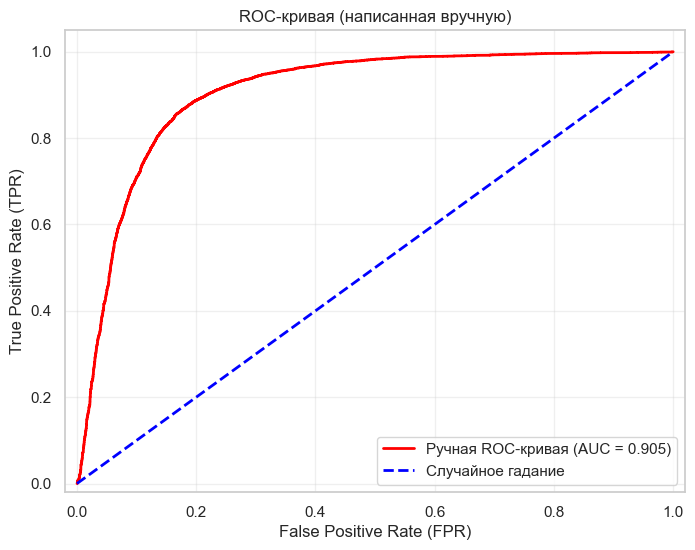

In [53]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_list, tpr_list, color='red', lw=2, label=f'Ручная ROC-кривая (AUC = {auc_manual:.3f})')

plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--', label='Случайное гадание')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая (написанная вручную)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

In [54]:
roc_auc_score(y_true, y_prob)

0.9050957326124472